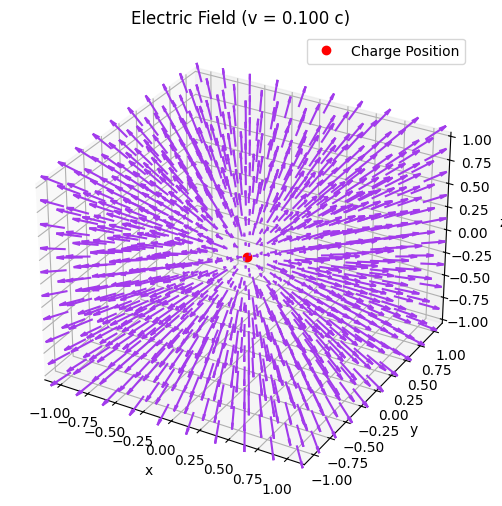

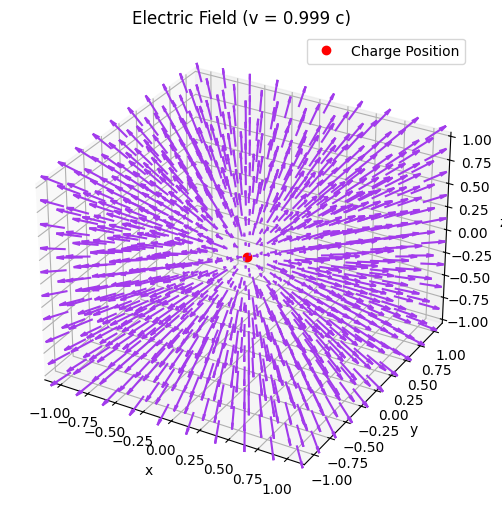

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
q = 1.6e-19 #charge of electron in coloumbs
c = 3e8     #speed of light in m/s
v_values = [0.1*c, 0.999*c] #velocities in m/s
t = 0       #considered time is 0 as the shape of field lines does not change with respect to time 

# 3D grid to create vectors
x = np.linspace(-1, 1, 10)
y = np.linspace(-1, 1, 10)
z = np.linspace(-1, 1, 10)
X, Y, Z = np.meshgrid(x, y, z) # Generates 3D arrays representing coordinates of each point on the (x, y, z) grid.

for v in v_values:
# Electric Field components
    beta = v / c
    denom = ((X - v*t)**2 + ((1 - beta**2)*(Y**2+Z**2)))**(3/2)
    Ex = q * (1 - beta**2) * (X - v*t) / denom
    Ey = q * (1 - beta**2) * Y / denom
    Ez = q * (1 - beta**2) * Z / denom
# Normalize field (gives direction of the field)
    Emag = np.sqrt(Ex**2 + Ey**2 + Ez**2)
    Ex, Ey, Ez = Ex / Emag, Ey / Emag, Ez / Emag
# Create 3D quiver plot
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.quiver(X, Y, Z, Ex, Ey, Ez, length=0.2, normalize=True, color='#A23BEC')
    ax.plot(0, 0, 0, 'ro', label='Charge Position')
    ax.set_title(f'Electric Field (v = {v/c:.3f} c)')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.legend()

plt.show()

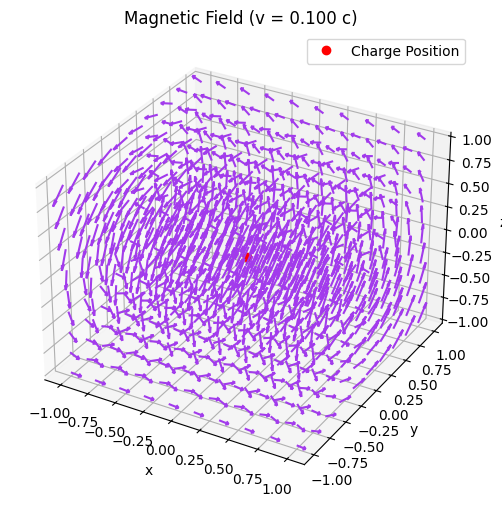

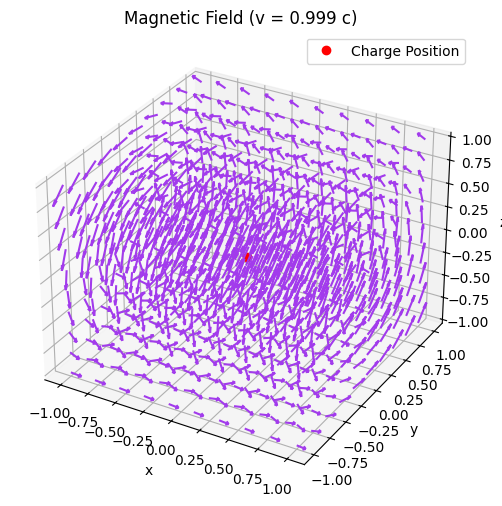

In [2]:
for v in v_values:
# Electric Field components
    beta = v / c
    denom = ((X - v*t)**2 + ((1 - beta**2)*(Y**2+Z**2)))**(3/2)
   
    Bx = np.zeros_like(X)  
    By = -q * (1 - beta**2) * Z / denom
    Bz = q * (1 - beta**2) * Y / denom
# Normalize field (gives direction of the field)
    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)
    Bmag = np.where(Bmag == 0, 1, Bmag)
    Bx, By, Bz = Bx / Bmag, By / Bmag, Bz / Bmag
# Create 3D quiver plot
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.quiver(X, Y, Z, Bx, By, Bz, length=0.2, normalize=True, color='#A23BEC')

    ax.plot(0, 0, 0, 'ro', label='Charge Position')
    ax.set_title(f'Magnetic Field (v = {v/c:.3f} c)')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.legend()

plt.show()

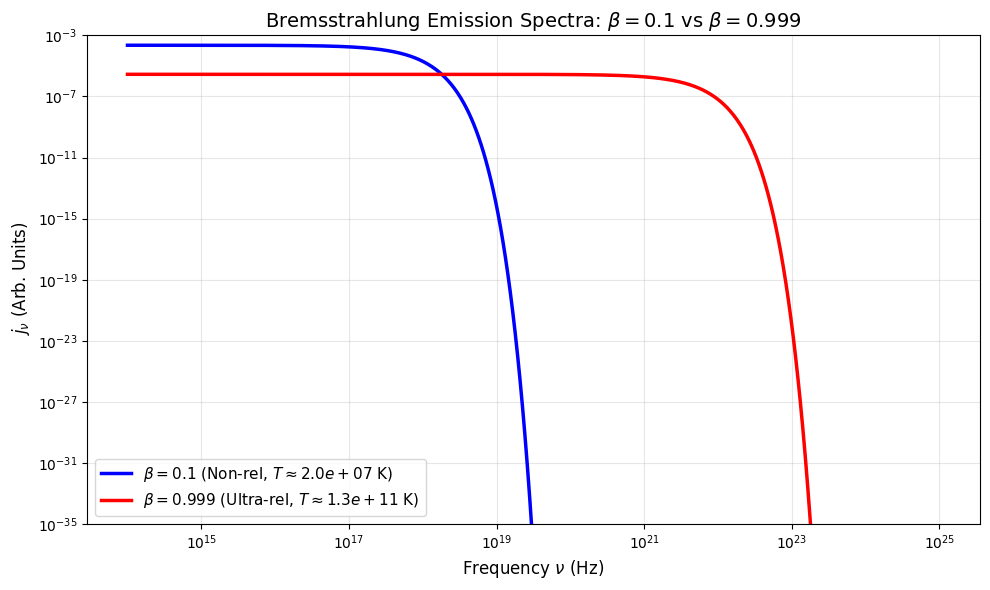

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Fundamental Constants (CGS units) ---
h = 6.626e-27      # Planck constant (erg*s)
kb = 1.38e-16      # Boltzmann constant (erg/K)
me = 9.11e-28      # Electron mass (g)
c = 3.0e10         # Speed of light (cm/s)

# --- Define Temperature based on your derivations ---
# Case (a): beta = 0.1 (Non-relativistic)
beta_a = 0.1
T_a = (me * (beta_a * c)**2) / (3 * kb)  # Approx 10^7 K

# Case (b): beta = 0.999 (Relativistic)
beta_b = 0.999
gamma_b = 1 / np.sqrt(1 - beta_b**2)
T_b = (gamma_b - 1) * me * c**2 / kb    # Approx 10^11 K

# --- Frequency range: from IR (10^14) to Gamma Rays (10^24 Hz) ---
nu = np.logspace(14, 25, 1000)

def bremsstrahlung_spectrum(T, nu):
    r"""
    Thermal Bremsstrahlung Emissivity Formula:
    
    j_nu \propto T^-1/2 * exp(-h*nu/kT) * g_ff

    Keeping Gaunt factor as a factor (constant)
    """
    return (T**-0.5) * np.exp(-h * nu / (kb * T))

# Calculate spectra
spec_a = bremsstrahlung_spectrum(T_a, nu)
spec_b = bremsstrahlung_spectrum(T_b, nu)

# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.loglog(nu, spec_a, label=f'$\\beta=0.1$ (Non-rel, $T \\approx {T_a:.1e}$ K)', color='blue', lw=2.5)
plt.loglog(nu, spec_b, label=f'$\\beta=0.999$ (Ultra-rel, $T \\approx {T_b:.1e}$ K)', color='red', lw=2.5)

# Formatting the plot
plt.title('Bremsstrahlung Emission Spectra: $\\beta=0.1$ vs $\\beta=0.999$', fontsize=14)
plt.xlabel('Frequency $\\nu$ (Hz)', fontsize=12)
plt.ylabel(' $j_\\nu$ (Arb. Units)', fontsize=12)
plt.ylim(1e-35, 1e-3)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc='best', fontsize=11)



plt.tight_layout()
plt.show()